# 04 - PatchCore Experiments

The autoencoder validates the unsupervised idea but its reconstructions are blurry and we suspect it will struggle on textures. PatchCore (Roth et al., 2022) takes a fundamentally different approach built on **transfer learning**:

1. extract patch level features from a CNN backbone pretrained on ImageNet, without any fine tuning
2. store the features of all normal training patches in a **memory bank**
3. shrink the bank with **coreset subsampling** so inference stays fast
4. at test time, score each patch by the distance to its **nearest neighbour** in the bank

No gradient training happens at all. Mid level ImageNet features (edges, textures, object parts) transfer remarkably well to industrial images, which is the whole bet of this method.

In this notebook we build a minimal PatchCore from scratch with a ResNet18 backbone to understand every step, then hand over to anomalib's production implementation. Run it inside the project `.venv` (the first run downloads pretrained weights).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

DATA_ROOT = Path('../data/mvtec_ad')
IMG_SIZE = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CATEGORY = 'bottle'

torch.manual_seed(42)
np.random.seed(42)
print('device:', DEVICE)

device: cpu


## 1. Patch Level Feature Extraction

We register forward hooks on **layer2 and layer3** of a pretrained ResNet18. These middle layers capture mid level visual patterns and keep useful spatial resolution (32x32 and 16x16 for a 256x256 input). Deeper layers are too semantic (they answer "what object is this", which is useless when every image shows a bottle) and earlier layers are too low level.

Every spatial position in a feature map summarizes a **patch** of the input image (its receptive field), so a feature map of shape 32x32x128 is really 1024 patch descriptors of dimension 128. To combine the two layers we upsample layer3 to layer2's resolution and concatenate along channels, giving one 384 dimensional descriptor per patch. PatchCore additionally smooths each descriptor with local average pooling to give it a slightly larger effective receptive field.

Since the backbone is frozen we also need ImageNet normalization on the inputs, exactly the preprocessing scheme worked out in notebook 02.

In [2]:
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
backbone.eval().to(DEVICE)

features = {}


def hook(name):
    def fn(module, inputs, output):
        features[name] = output.detach()
    return fn


backbone.layer2.register_forward_hook(hook('layer2'))
backbone.layer3.register_forward_hook(hook('layer3'))

imagenet_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


@torch.no_grad()
def extract_patch_features(image_batch):
    """Returns per patch descriptors [B, H2*W2, C2+C3] at layer2 resolution."""
    backbone(image_batch.to(DEVICE))
    f2, f3 = features['layer2'], features['layer3']
    # local smoothing (PatchCore uses a 3x3 neighbourhood aggregation)
    f2 = F.avg_pool2d(f2, kernel_size=3, stride=1, padding=1)
    f3 = F.avg_pool2d(f3, kernel_size=3, stride=1, padding=1)
    # bring layer3 up to layer2 resolution and concatenate channels
    f3 = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
    fmap = torch.cat([f2, f3], dim=1)                    # [B, C, H2, W2]
    B, C, H, W = fmap.shape
    return fmap.permute(0, 2, 3, 1).reshape(B, H * W, C), (H, W)


demo = imagenet_tf(Image.open(sorted((DATA_ROOT / CATEGORY / 'train' / 'good').glob('*.png'))[0]).convert('RGB'))
patches, grid = extract_patch_features(demo.unsqueeze(0))
print(f'layer2 map: {tuple(features["layer2"].shape)}')
print(f'layer3 map: {tuple(features["layer3"].shape)}')
print(f'patch descriptors per image: {patches.shape[1]} of dimension {patches.shape[2]} (grid {grid[0]}x{grid[1]})')

layer2 map: (1, 128, 32, 32)
layer3 map: (1, 256, 16, 16)
patch descriptors per image: 1024 of dimension 384 (grid 32x32)


## 2. Building the Memory Bank

We extract patch descriptors from a subset of the defect free training images and stack them into one big matrix, the memory bank of normal appearance. Using a subset keeps the notebook quick; the production run uses every training image.

In [3]:
train_paths = sorted((DATA_ROOT / CATEGORY / 'train' / 'good').glob('*.png'))[:60]

bank_parts = []
for p in train_paths:
    img = imagenet_tf(Image.open(p).convert('RGB')).unsqueeze(0)
    patches, grid = extract_patch_features(img)
    bank_parts.append(patches[0].cpu())
memory_bank = torch.cat(bank_parts, dim=0)
print(f'memory bank: {tuple(memory_bank.shape)} '
      f'({memory_bank.shape[0]:,} patches from {len(train_paths)} images)')

memory bank: (61440, 384) (61,440 patches from 60 images)


## 3. Coreset Subsampling

Nearest neighbour search over every stored patch would be slow and redundant since neighbouring patches are highly similar. Coreset subsampling keeps a small subset that still **covers** the feature space: greedy farthest point sampling repeatedly picks the patch that is farthest from everything already selected. We reduce the bank to 10 percent, the same ratio used in the pipeline.

In [4]:
@torch.no_grad()
def coreset_subsample(bank, ratio=0.1, seed=42):
    """Greedy farthest point (k center) selection."""
    bank = bank.to(DEVICE)
    n_select = max(1, int(len(bank) * ratio))
    gen = torch.Generator(device='cpu').manual_seed(seed)
    selected = [int(torch.randint(len(bank), (1,), generator=gen))]
    min_dists = torch.cdist(bank, bank[selected[-1]:selected[-1] + 1]).squeeze(1)
    for _ in range(n_select - 1):
        idx = int(min_dists.argmax())
        selected.append(idx)
        new_d = torch.cdist(bank, bank[idx:idx + 1]).squeeze(1)
        min_dists = torch.minimum(min_dists, new_d)
    return bank[selected].cpu()


coreset = coreset_subsample(memory_bank, ratio=0.1)
print(f'coreset: {tuple(coreset.shape)} ({100 * len(coreset) / len(memory_bank):.0f} percent of the bank)')

coreset: (6144, 384) (10 percent of the bank)


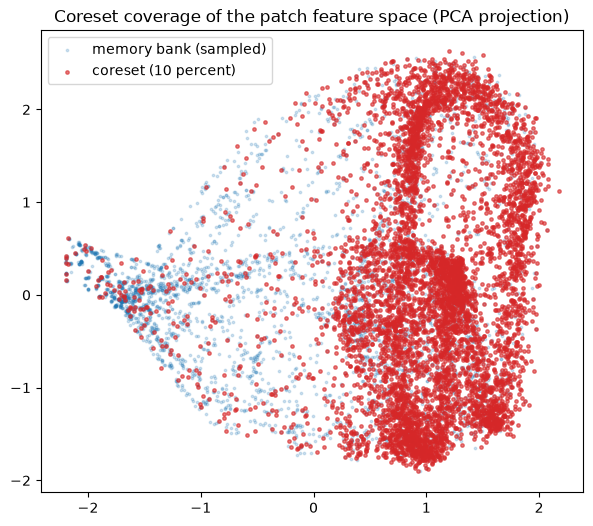

In [5]:
# visualize coverage: project bank and coreset to 2D with PCA
sample_idx = torch.randperm(len(memory_bank))[:4000]
sample = memory_bank[sample_idx]
mean = sample.mean(dim=0)
_, _, V = torch.pca_lowrank(sample - mean, q=2)
bank_2d = (sample - mean) @ V
core_2d = (coreset - mean) @ V

plt.figure(figsize=(7, 6))
plt.scatter(bank_2d[:, 0], bank_2d[:, 1], s=3, alpha=0.2, label='memory bank (sampled)')
plt.scatter(core_2d[:, 0], core_2d[:, 1], s=6, alpha=0.6, color='tab:red', label='coreset (10 percent)')
plt.title('Coreset coverage of the patch feature space (PCA projection)')
plt.legend()
plt.show()

The red coreset points spread across the whole cloud instead of clustering in dense areas, which is exactly the point: coverage of the normal feature space with a tenth of the patches.

## 4. Nearest Neighbour Anomaly Scoring

At test time each patch descriptor is compared with its nearest neighbour in the coreset. That distance is the patch's anomaly score: a patch that looks like some normal training patch scores low and a patch unlike anything in the bank scores high. Reshaping the per patch scores to the feature grid gives a coarse anomaly map, which we upsample bilinearly to image resolution. The image level score is the maximum patch distance.

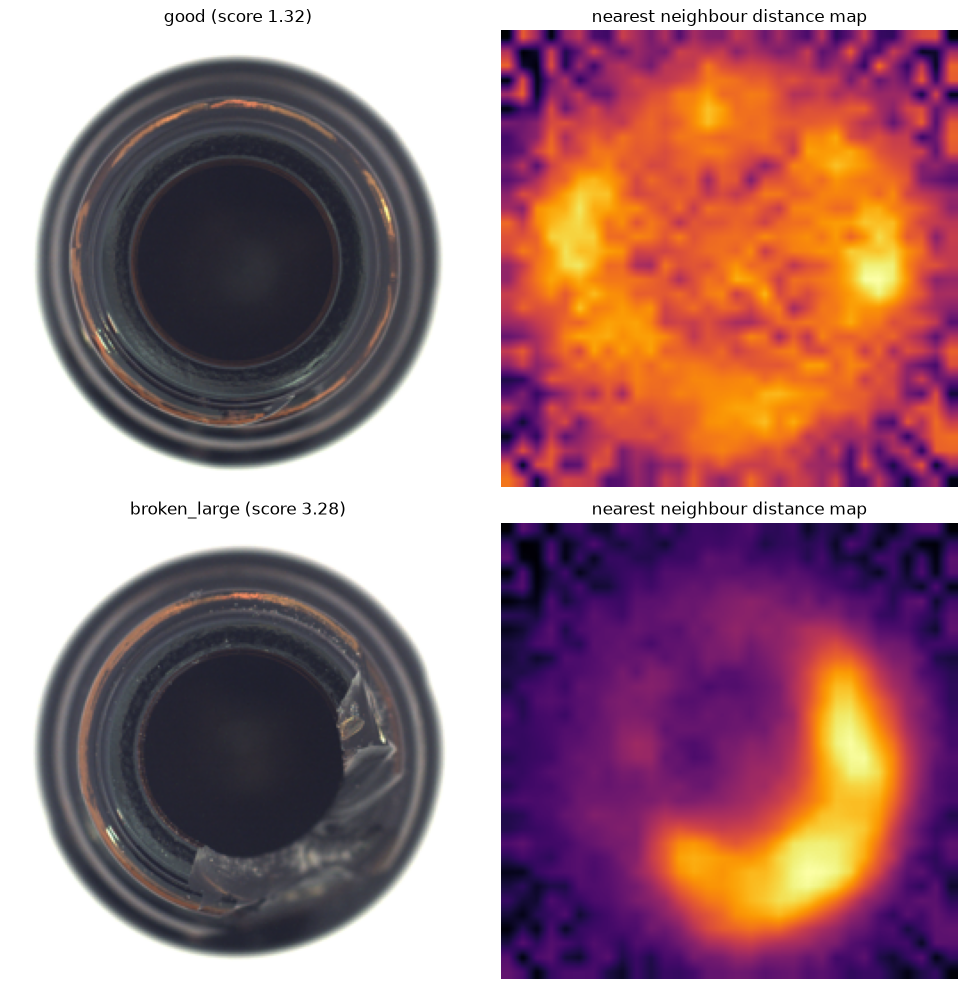

In [6]:
@torch.no_grad()
def patchcore_anomaly_map(image_tensor, coreset, img_size=IMG_SIZE):
    patches, (H, W) = extract_patch_features(image_tensor.unsqueeze(0))
    dists = torch.cdist(patches[0].to(DEVICE), coreset.to(DEVICE))  # [n_patches, n_coreset]
    nn_dist = dists.min(dim=1).values                               # nearest neighbour distance
    amap = nn_dist.reshape(1, 1, H, W)
    amap = F.interpolate(amap, size=(img_size, img_size), mode='bilinear', align_corners=False)
    return amap[0, 0].cpu().numpy(), float(nn_dist.max())


# compare one good and one defective test image
test_dir = DATA_ROOT / CATEGORY / 'test'
good_path = sorted((test_dir / 'good').glob('*.png'))[0]
defect_dir = next(d for d in sorted(test_dir.iterdir()) if d.is_dir() and d.name != 'good')
defect_path = sorted(defect_dir.glob('*.png'))[0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for row, p in enumerate([good_path, defect_path]):
    img = imagenet_tf(Image.open(p).convert('RGB'))
    amap, score = patchcore_anomaly_map(img, coreset)
    display = np.asarray(Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))) / 255.0
    axes[row, 0].imshow(display)
    axes[row, 0].set_title(f'{p.parent.name} (score {score:.2f})')
    axes[row, 1].imshow(amap, cmap='inferno')
    axes[row, 1].set_title('nearest neighbour distance map')
    for ax in axes[row]:
        ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Mini Evaluation

To check that the idea works beyond single examples we score a subset of the test set and measure the image level AUROC of our minimal implementation.

images scored: 40
image AUROC (minimal PatchCore, ResNet18): 1.0000


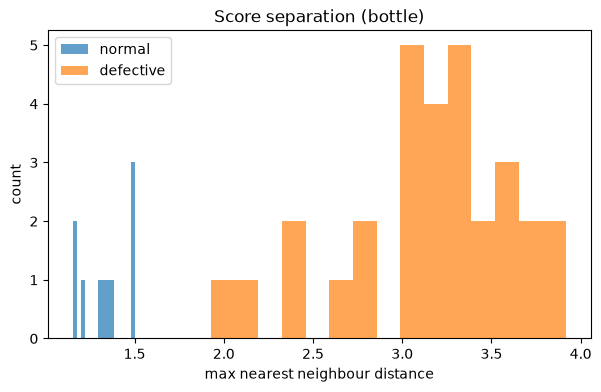

In [7]:
from sklearn.metrics import roc_auc_score

labels, scores = [], []
for d in sorted(test_dir.iterdir()):
    if not d.is_dir():
        continue
    for p in sorted(d.glob('*.png'))[:10]:  # subset per defect type for speed
        img = imagenet_tf(Image.open(p).convert('RGB'))
        _, score = patchcore_anomaly_map(img, coreset)
        labels.append(0 if d.name == 'good' else 1)
        scores.append(score)

labels, scores = np.array(labels), np.array(scores)
print(f'images scored: {len(labels)}')
print(f'image AUROC (minimal PatchCore, ResNet18): {roc_auc_score(labels, scores):.4f}')

plt.figure(figsize=(7, 4))
plt.hist(scores[labels == 0], bins=15, alpha=0.7, label='normal')
plt.hist(scores[labels == 1], bins=15, alpha=0.7, label='defective')
plt.xlabel('max nearest neighbour distance')
plt.ylabel('count')
plt.title(f'Score separation ({CATEGORY})')
plt.legend()
plt.show()

Even this stripped down version separates normal from defective images almost perfectly, with **no training at all**, only feature extraction and nearest neighbour lookup. That confirmed PatchCore as our main method.

## 6. From Prototype to anomalib

For the pipeline we use anomalib's `Patchcore`, which adds the pieces our prototype simplifies: an optimized sparse projection based coreset selection, reweighted neighbourhood scoring for the image score and Gaussian smoothing of the anomaly map. The production configuration uses the larger **WideResNet50** backbone (the ablation in `scripts/ablation_backbone.py` compares it against ResNet18) with the same layer2 plus layer3 features and a 0.1 coreset ratio.

One integration detail: our anomalib version has a bug where a pandas Series is compared against a `Split` enum, which silently matches nothing. The monkey patch in `src/anomalib_compat.py` coerces the enum to a plain string before the comparison.

In [8]:
# Production usage, exactly as in scripts/train_patchcore.py.
# Building the memory bank for one category takes a few minutes on CPU.
# Progress bars and the model summary are disabled here: Lightning's rich
# based progress rendering redirects stdout inside Jupyter and anomalib's
# coreset progress output then recurses through that redirect until it
# raises a RecursionError. Disabling them avoids the conflict. The script
# version runs in a terminal where the issue does not exist.
import sys
sys.path.insert(0, '..')

from anomalib.data import MVTecAD
from anomalib.engine import Engine
from anomalib.models import Patchcore

from src.anomalib_compat import patch_split_enum_bug
patch_split_enum_bug()

datamodule = MVTecAD(root=str(DATA_ROOT.resolve()), category=CATEGORY, num_workers=0)
model = Patchcore(backbone='wide_resnet50_2', layers=['layer2', 'layer3'],
                  coreset_sampling_ratio=0.1)
engine = Engine(max_epochs=1, accelerator='auto', devices=1,
                enable_progress_bar=False, enable_model_summary=False)

engine.fit(model=model, datamodule=datamodule)
test_results = engine.test(model=model, datamodule=datamodule)
print(test_results)


m:\Git_repos\PROJECTS\Industrial Surface Defect Detection\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
m:\Git_repos\PROJECTS\Industrial Surface Defect Detection\.venv\Lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer
m:\Git_repos\PROJECTS\Industrial Surface Defect Detection\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is de

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │            1.0            │
│       image_F1Score       │    0.9919999837875366     │
│        pixel_AUROC        │    0.9855641722679138     │
│       pixel_F1Score       │    0.7259702086448669     │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 1.0, 'image_F1Score': 0.9919999837875366, 'pixel_AUROC': 0.9855641722679138, 'pixel_F1Score': 0.7259702086448669}]


## 7. Conclusions

- Pretrained mid level features separate normal from defective patches without any fine tuning on our data.
- Coreset subsampling keeps 10 percent of the patches while preserving coverage of the normal feature space.
- The minimal implementation already reaches near perfect image AUROC on bottle, so the approach clearly outclasses the reconstruction baseline.
- The full anomalib based runs for all categories live in `scripts/train_patchcore.py` and the backbone comparison lives in `scripts/ablation_backbone.py`.